In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
!pip install openpyxl

DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\argparse-1.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\astor-0.8.1-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\pyggi-2.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run:

In [3]:
df = pd.read_excel("Online Retail.xlsx")
print(df.head)
print(df.shape)
print(df.info())

<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Custom

Handle Missing Values

In [4]:
print("Before removing missing values:\n", df.isna().sum())

Before removing missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
df = df[df["Description"].notna() & (df["Description"] != "")]
print("After removing missing values:\n", df.isna().sum())

After removing missing values:
 InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64


Remove invalid records

In [6]:
bad_cnt = df[(df["Quantity"] <= 0)].shape[0]
print("Rows with zero or negative quantity BEFORE:", bad_cnt)

df_clean = df[df["Quantity"] > 0]
after_cnt = df_clean[(df_clean["Quantity"] <= 0)].shape[0]
print("Rows with zero or negative quantity AFTER:", after_cnt)

Rows with zero or negative quantity BEFORE: 9762
Rows with zero or negative quantity AFTER: 0


In [7]:
bad_cnt = df[(df["UnitPrice"] <= 0)].shape[0]
print("Rows with zero or negative UnitPrice BEFORE:", bad_cnt)

df_clean = df[df["UnitPrice"] > 0]
after_cnt = df_clean[(df_clean["UnitPrice"] <= 0)].shape[0]
print("Rows with zero or negative quantity AFTER:", after_cnt)

Rows with zero or negative UnitPrice BEFORE: 1063
Rows with zero or negative quantity AFTER: 0


Data type conversion

In [8]:
print("BEFORE: ", df["InvoiceDate"].dtype)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("AFTER: ", df["InvoiceDate"].dtype)

BEFORE:  datetime64[ns]
AFTER:  datetime64[ns]


Feature engineering

In [9]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
print(df["Quantity"].head, df["UnitPrice"].head, df["TotalAmount"].head)

<bound method NDFrame.head of 0          6
1          6
2          8
3          6
4          6
          ..
541904    12
541905     6
541906     4
541907     4
541908     3
Name: Quantity, Length: 540455, dtype: int64> <bound method NDFrame.head of 0         2.55
1         3.39
2         2.75
3         3.39
4         3.39
          ... 
541904    0.85
541905    2.10
541906    4.15
541907    4.15
541908    4.95
Name: UnitPrice, Length: 540455, dtype: float64> <bound method NDFrame.head of 0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: TotalAmount, Length: 540455, dtype: float64>


In [10]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [11]:
original_count = df.shape[0]
df_grouped = df.groupby(["InvoiceNo", "Description"], as_index=False)["Quantity"].sum()

new_count = df_grouped.shape[0]
print("Before:", original_count)
print("After:", new_count)

print(df_grouped.columns)

Before: 531167
After: 520448
Index(['InvoiceNo', 'Description', 'Quantity'], dtype='object')


In [12]:
product_counts = df_grouped["Description"].value_counts()
frequent_products = product_counts[product_counts >= 10].index
df_filtered = df_grouped[df_grouped["Description"].isin(frequent_products)]
print(df_filtered["Description"].value_counts().min())

10


Preprocessing for Association Rule Mining

In [13]:
baskets = df_grouped.groupby("InvoiceNo")["Description"].apply(list).reset_index()
print(baskets.head)

<bound method NDFrame.head of       InvoiceNo                                        Description
0        536365  [CREAM CUPID HEARTS COAT HANGER, GLASS STAR FR...
1        536366  [HAND WARMER RED POLKA DOT, HAND WARMER UNION ...
2        536367  [ASSORTED COLOUR BIRD ORNAMENT, BOX OF 6 ASSOR...
3        536368  [BLUE COAT RACK PARIS FASHION, JAM MAKING SET ...
4        536369                         [BATH BUILDING BLOCK WORD]
...         ...                                                ...
20605    581586  [DOORMAT RED RETROSPOT, LARGE CAKE STAND  HANG...
20606    581587  [ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKEL...
20607   A563185                                  [Adjust bad debt]
20608   A563186                                  [Adjust bad debt]
20609   A563187                                  [Adjust bad debt]

[20610 rows x 2 columns]>


Preprocessing for Time Series Analysis

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='object')


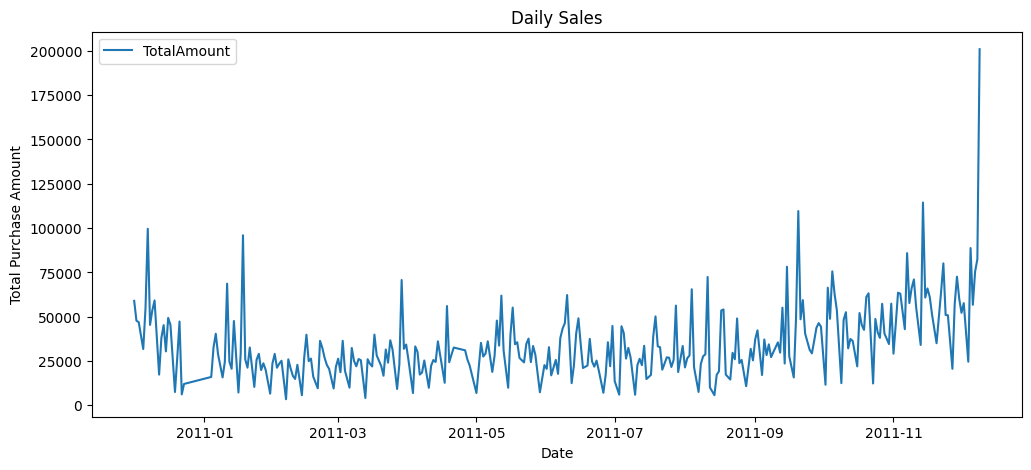

In [ ]:
print(df.columns)

df["InvoiceDay"] = df["InvoiceDate"].dt.date
daily_sales = df.groupby("InvoiceDay")["TotalAmount"].sum().reset_index()
daily_sales.columns = ["Date", "TotalAmount"]
daily_sales = daily_sales.sort_values("Date")

daily_sales.plot(x="Date", y="TotalAmount", kind="line", figsize=(12,5))
plt.ylabel("Total Purchase Amount")
plt.title("Daily Sales")
plt.show()

Exploratory Data Analysis (EDA)

General Dataset Exploration 

            Quantity                    InvoiceDate      UnitPrice  \
count  373995.000000                         373995  373995.000000   
mean        6.543542  2011-07-07 18:53:49.269963776       1.864739   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         1.000000            2011-03-30 17:33:00       0.950000   
50%         4.000000            2011-07-24 14:33:00       1.650000   
75%        12.000000            2011-10-21 13:17:00       2.550000   
max        24.000000            2011-12-09 12:50:00       4.130000   
std         6.378084                            NaN       1.042095   

          CustomerID    TotalAmount  
count  285483.000000  373995.000000  
mean    15335.240284      10.073433  
min     12347.000000       0.001000  
25%     14009.000000       2.550000  
50%     15271.000000       6.580000  
75%     16839.000000      15.000000  
max     18287.000000      99.120000  
std      1711.836806      10.280673   Index(['InvoiceNo', 'StockC

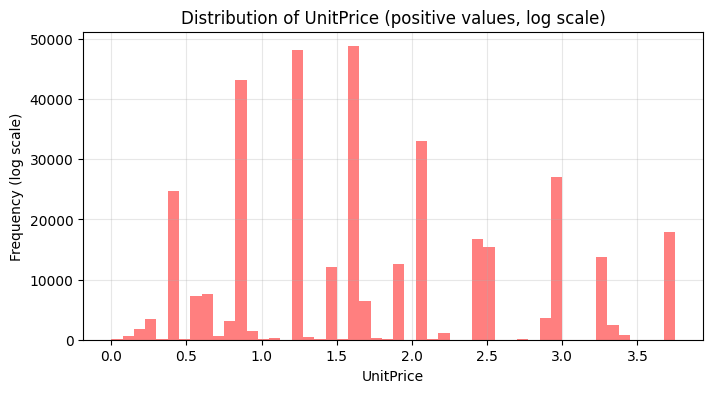

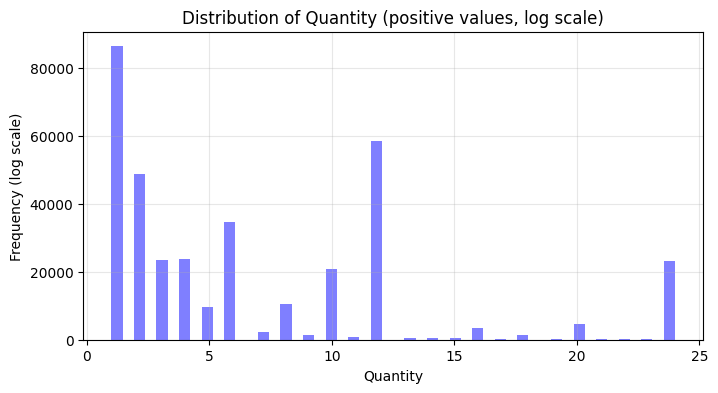

Description
WHITE HANGING HEART T-LIGHT HOLDER     1724
JUMBO BAG RED RETROSPOT                1351
ASSORTED COLOUR BIRD ORNAMENT          1235
PACK OF 72 RETROSPOT CAKE CASES        1229
LUNCH BAG RED RETROSPOT                1207
JAM MAKING SET PRINTED                 1105
HEART OF WICKER SMALL                  1066
LUNCH BAG  BLACK SKULL.                1061
SET OF 4 PANTRY JELLY MOULDS           1040
LUNCH BAG SPACEBOY DESIGN               988
REX CASH+CARRY JUMBO SHOPPER            963
LUNCH BAG CARS BLUE                     949
NATURAL SLATE HEART CHALKBOARD          941
SET/20 RED RETROSPOT PAPER NAPKINS      932
LUNCH BAG PINK POLKADOT                 921
Name: count, dtype: int64


C:\Users\RayanTech\AppData\Local\Temp\ipykernel_17484\548173900.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


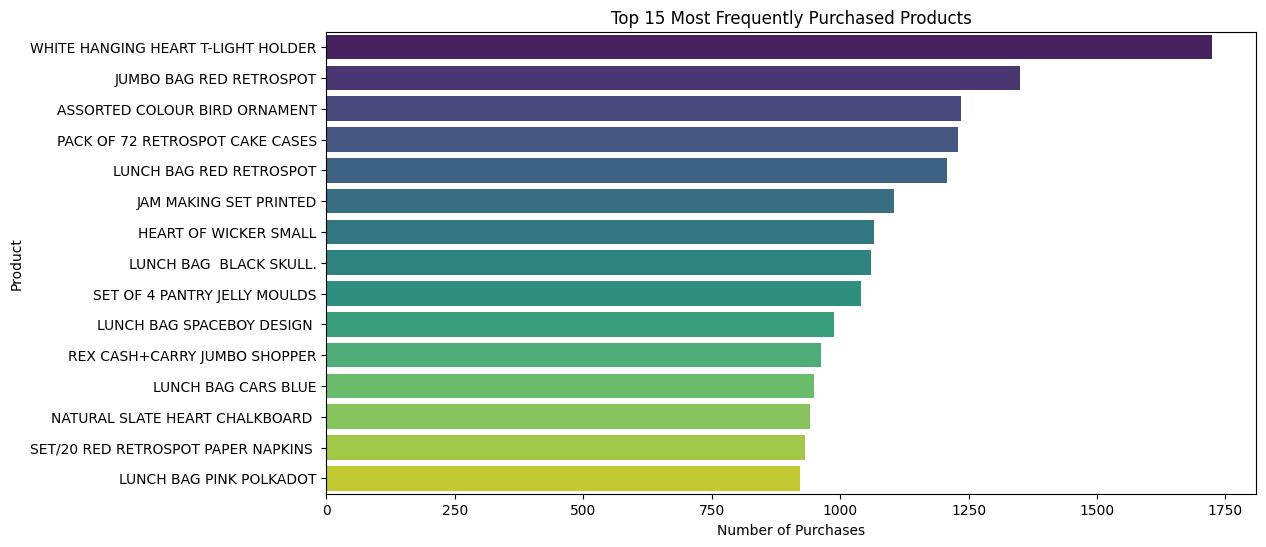

C:\Users\RayanTech\AppData\Local\Temp\ipykernel_17484\548173900.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.values, y=country_sales.index, palette="coolwarm")


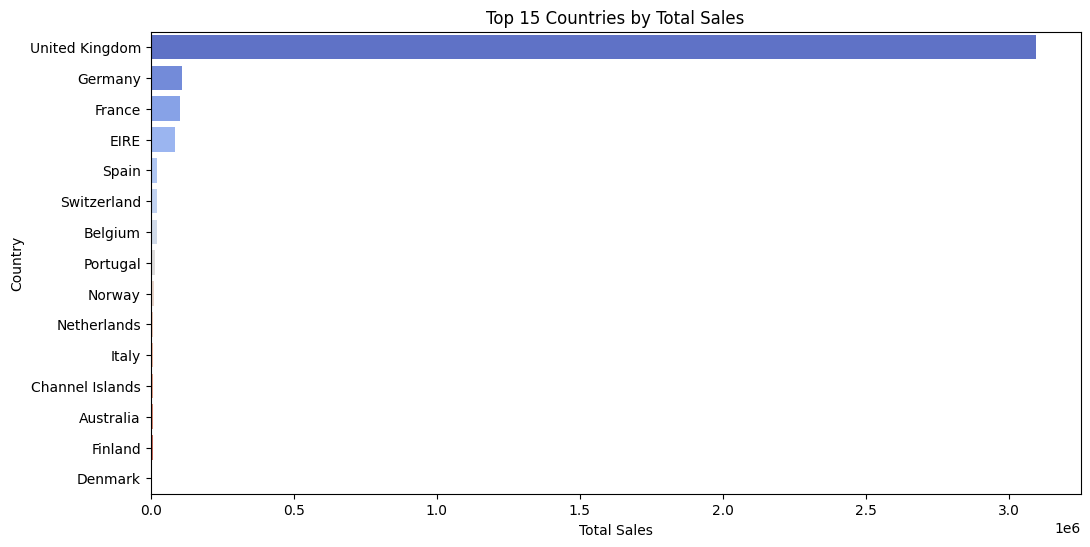

In [27]:
print(df.describe(), df.columns)

price_95 = df["UnitPrice"].quantile(0.95)
quantity_95 = df["Quantity"].quantile(0.95)
df = df[(df["UnitPrice"] <= price_95) & (df["Quantity"] <= quantity_95)]
df_filtered = df[(df["Quantity"] > 0) & 
                 (df["UnitPrice"] > 0) & 
                 (df["UnitPrice"] <= price_95) & 
                 (df["Quantity"] <= quantity_95)]
plt.figure(figsize=(8, 4))
plt.hist(df["UnitPrice"], bins=50, alpha=0.5, color='red')
plt.xlabel("UnitPrice")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of UnitPrice (positive values, log scale)")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df["Quantity"], bins=50, alpha=0.5, color='blue')
plt.xlabel("Quantity")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Quantity (positive values, log scale)")
plt.grid(alpha=0.3)
plt.show()

top_products = df["Description"].value_counts().head(15)
print(top_products)

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Top 15 Most Frequently Purchased Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")
plt.show()

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
country_sales = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False).head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=country_sales.values, y=country_sales.index, palette="coolwarm")
plt.title("Top 15 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")
plt.show()

EDA for Association Rules 

      InvoiceNo                                        Description
0        536365  [CREAM CUPID HEARTS COAT HANGER, GLASS STAR FR...
1        536366  [HAND WARMER RED POLKA DOT, HAND WARMER UNION ...
2        536367  [ASSORTED COLOUR BIRD ORNAMENT, BOX OF 6 ASSOR...
3        536368  [BLUE COAT RACK PARIS FASHION, JAM MAKING SET ...
4        536369                         [BATH BUILDING BLOCK WORD]
...         ...                                                ...
20605    581586  [DOORMAT RED RETROSPOT, LARGE CAKE STAND  HANG...
20606    581587  [ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKEL...
20607   A563185                                  [Adjust bad debt]
20608   A563186                                  [Adjust bad debt]
20609   A563187                                  [Adjust bad debt]

[20610 rows x 2 columns]
  InvoiceNo                                        Description  NumProducts
0    536365  [CREAM CUPID HEARTS COAT HANGER, GLASS STAR FR...            7
1    536366  [HAND

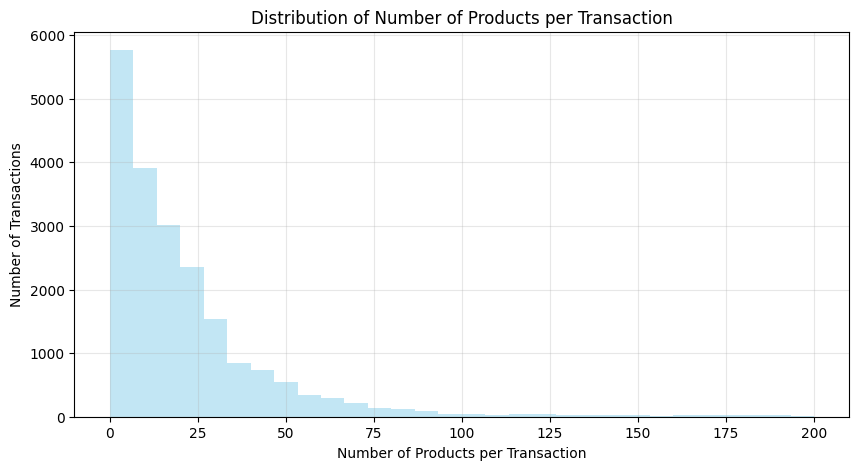

Mean products per transaction: 25.252207666181466
Median products per transaction: 15.0
Max products per transaction: 1108


In [16]:
print(baskets)
baskets["NumProducts"] = baskets["Description"].apply(len)
print(baskets.head())

plt.figure(figsize=(10,5))
plt.hist(baskets["NumProducts"], bins=30, range=(0, 200), color="skyblue", alpha=0.5)
plt.xlabel("Number of Products per Transaction")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Number of Products per Transaction")
plt.grid(alpha=0.3)
plt.show()

print("Mean products per transaction:", baskets["NumProducts"].mean())
print("Median products per transaction:", baskets["NumProducts"].median())
print("Max products per transaction:", baskets["NumProducts"].max())

      InvoiceNo                                        Description  \
0        536365  [CREAM CUPID HEARTS COAT HANGER, GLASS STAR FR...   
1        536366  [HAND WARMER RED POLKA DOT, HAND WARMER UNION ...   
2        536367  [ASSORTED COLOUR BIRD ORNAMENT, BOX OF 6 ASSOR...   
3        536368  [BLUE COAT RACK PARIS FASHION, JAM MAKING SET ...   
4        536369                         [BATH BUILDING BLOCK WORD]   
...         ...                                                ...   
20605    581586  [DOORMAT RED RETROSPOT, LARGE CAKE STAND  HANG...   
20606    581587  [ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKEL...   
20607   A563185                                  [Adjust bad debt]   
20608   A563186                                  [Adjust bad debt]   
20609   A563187                                  [Adjust bad debt]   

       NumProducts  
0                7  
1                2  
2               12  
3                4  
4                1  
...            ...  
20605       

C:\Users\RayanTech\AppData\Local\Temp\ipykernel_17484\3291989156.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.values, y=top_items.index, palette="viridis")


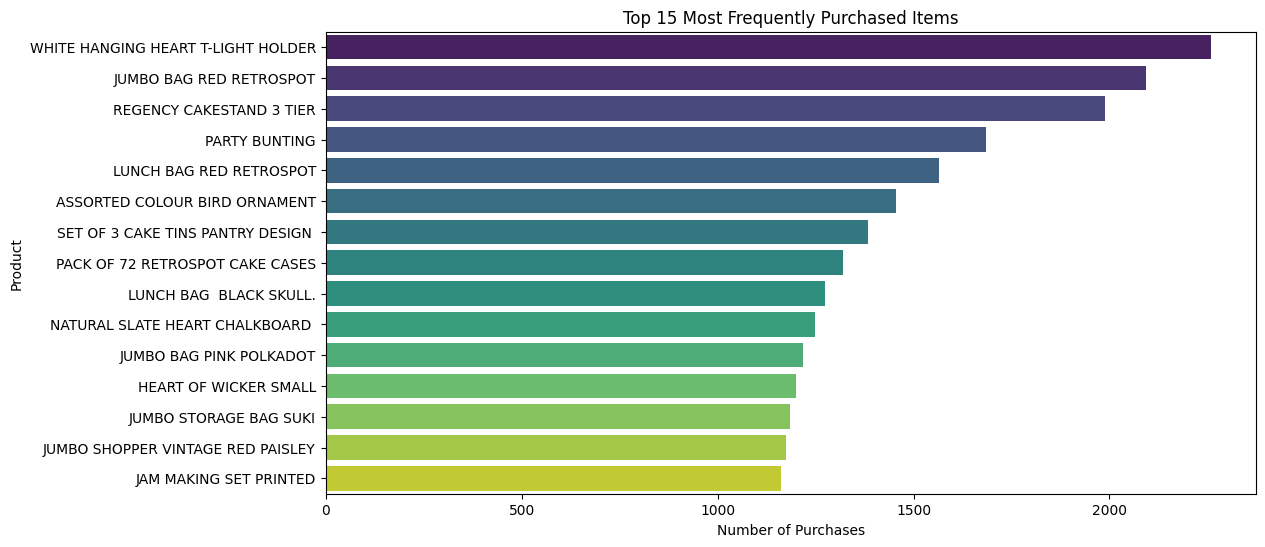

In [21]:
print(baskets)
all_items = baskets["Description"].explode()
item_counts = all_items.value_counts()
top_items = item_counts.head(15)
top_products = df["Description"].value_counts().head(15)

all_items = baskets["Description"].explode()
item_counts = all_items.value_counts() 
top_items = item_counts.head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=top_items.values, y=top_items.index, palette="viridis")
plt.title("Top 15 Most Frequently Purchased Items")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")
plt.show()


EDA for Time Series

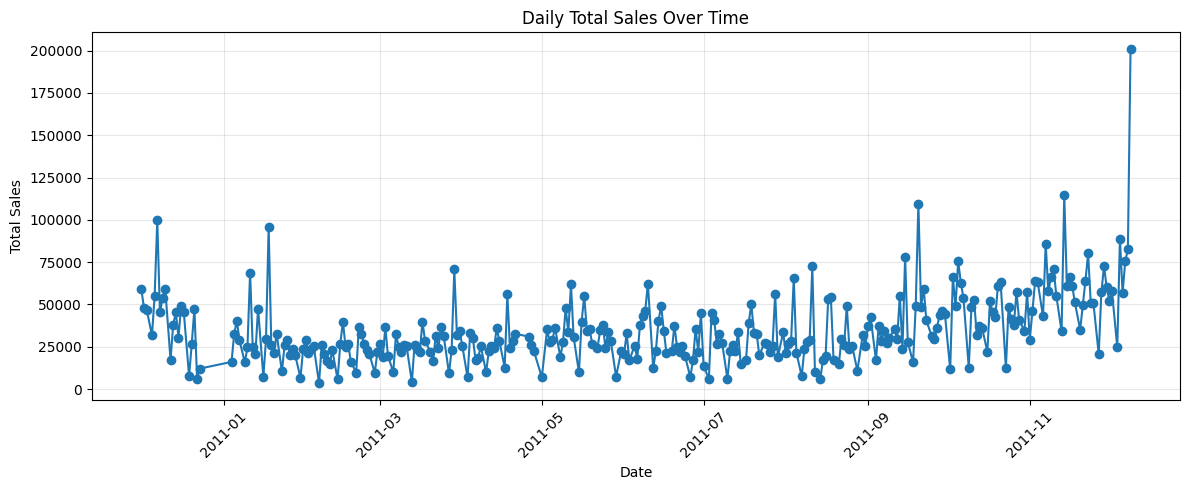

In [28]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales["Date"], daily_sales["TotalAmount"], marker='o', linestyle='-')
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Daily Total Sales Over Time")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

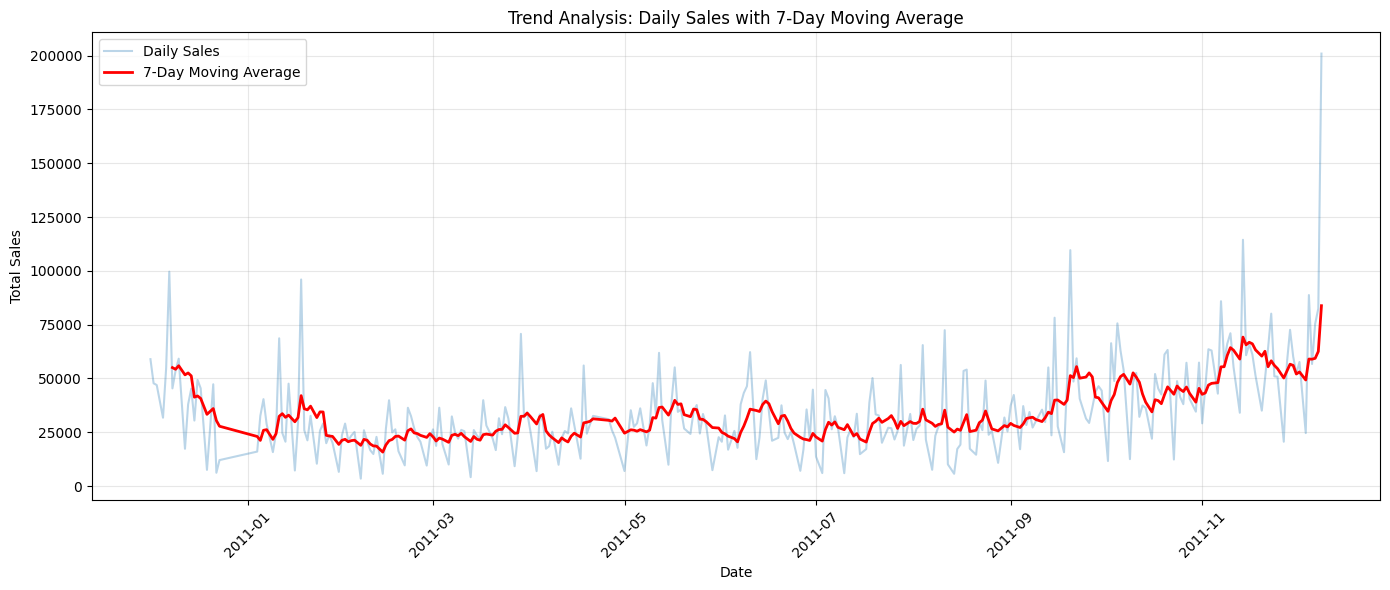

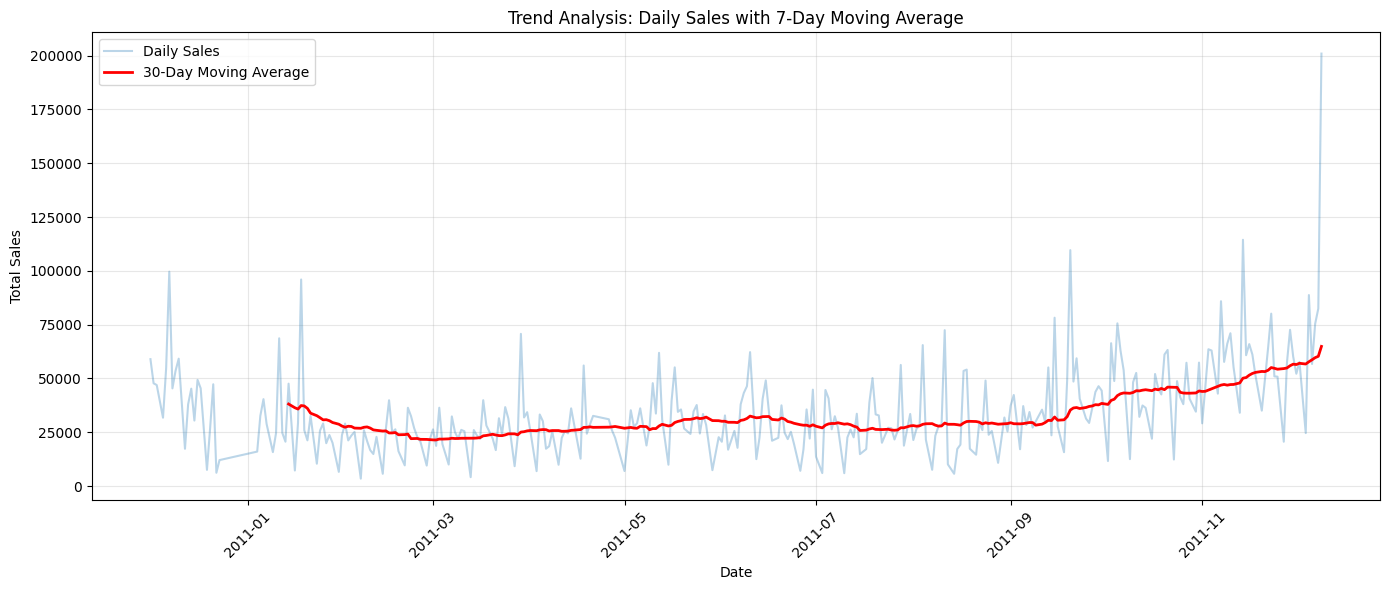

In [30]:
daily_sales["RollingMean_7"] = daily_sales["TotalAmount"].rolling(window=7).mean()

plt.figure(figsize=(14,6))
plt.plot(daily_sales["Date"], daily_sales["TotalAmount"], alpha=0.3, label="Daily Sales")  # raw daily sales
plt.plot(daily_sales["Date"], daily_sales["RollingMean_7"], color='red', linewidth=2, label="7-Day Moving Average")  # trend

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Trend Analysis: Daily Sales with 7-Day Moving Average")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

daily_sales["RollingMean_30"] = daily_sales["TotalAmount"].rolling(window=30).mean()

plt.figure(figsize=(14,6))
plt.plot(daily_sales["Date"], daily_sales["TotalAmount"], alpha=0.3, label="Daily Sales")  # raw daily sales
plt.plot(daily_sales["Date"], daily_sales["RollingMean_30"], color='red', linewidth=2, label="30-Day Moving Average")  # trend

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Trend Analysis: Daily Sales with 7-Day Moving Average")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()